<h1><center>Laboratorio 7: Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Matías Godoy
- Nombre de alumno 2: Delaney Tello


### **Link de repositorio de GitHub:** [Repositorio](https://github.com/MDS7202-GPT-6/GPT-6)

### Indice

1. [Temas a tratar](#Temas-a-tratar:)
3. [Descripcción del laboratorio](#Descripción-del-laboratorio.)
4. [Desarrollo](#Desarrollo)

## Temas a tratar

- Clasificación usando `XGBoost`.
- Métodos Agnósticos Globales de Interpretabilidad (`Partial Dependence Plot`, `Permutation Feature Importance`)
- Métodos Agnósticos Locales de Interpretabilidad (`Scoped Rules`, `SHAP`)

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.


### Objetivos principales del laboratorio

- Generar un pipeline de clasificación con `XGBoost`.
- Implementar modelos de interpretabilidad para explicar el funcionamiento del modelo de clasificación.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`, las cuales vale mencionar, son bastante más eficientes que los iteradores nativos sobre DataFrames.

# 1. Problemas Clínicos del Dr. Simi

<p align="center">
  <img src="https://gantz.cl/wp-content/uploads/2020/01/79024136_2718114448239059_7240913062570491904_o.jpg" width="350">
</p>

El reconocido **Dr. Simi**, famoso vendedor de medicamentos en latinoamerica, debido a la creciente prevalencia de enfermedades crónicas, como la diabetes, decidió abrir una clínica especializada en el tratamiento de esta enfermedad en nuestro país.

La clínica del Doctor Simi se convirtió en un lugar donde los pacientes con diabetes podrían recibir atención médica integral. El personal médico estaba compuesto por especialistas en endocrinología, nutrición y enfermería, todos capacitados en el manejo de la diabetes.

Sin embargo él se ha dado cuenta que los tiempos han cambiado y gracias a las tecnologías es posible generar mejores predicciones en la diabetes conociendo el historial médico de las personas. Por esto, el doctor se ha colocado una meta de incluir modelos de machine learning dentro de sus clínicas, para ello le ha solicitado crear un modelo capaz de predecir/clasificar diabetes pero le rogó que el desarrollo del modelo tuviera un especial enfoque en la interpretabilidad de lo que hace su modelo.

Para que usted pueda entrenar el modelo, Dr. Simi le ha entregado un dataset de todos los clientes que fueron detectados con diabetes a lo largo de la historia de la clinica. Con ello, adjunta el historial médico de las personas en forma de datos tabulares para que usted pueda realizar fácilmente la clasificación.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('diabetes_data.csv')
df.head(5)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clasificación de pacientes con diabetes (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/QH--g3ZaSbsAAAAC/dr-simi-abrazo.gif" width="400">
</p>

Tareas:
1. En primer lugar, el reconocido doctor le pide entrenar un modelo de `XGBoost` utilizando como target la columna `Diabetes` del dataset `diabetes_data.csv`. Para el entrenamiento, realice los siguientes pasos:
  * Realice una breve exploración de los datos y determine si aplicará transformaciones (MinMaxScaler, StandardScaler, etc.) en alguna/s de las variables. (1 punto)
  * Cree un conjunto de entrenamiento y uno de prueba, con una proporción de 1/3 en el conjunto de prueba. (0.5 puntos)
  * Cree un ColumnTransformer de preprocesamiento donde aplique las transformaciones determinadas anteriormente. Fije el parámetro `verbose_feature_names_out=False` y fije la salida del ColumnTransformer en formato pandas mediante el método `.set_output(transform='pandas')`. (1 punto)
  *  Cree un pipeline donde integre el preprocesamiento y el modelo `XGBoost` y entrene el modelo. Luego utilice `classification_report(..)` para reportar el desempeño del modelo. (1 punto)

Comente sus decisiones y los resultados obtenidos con el modelo.

2. Luego, le pide responder las siguientes preguntas:
  *  ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
  * ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
  * ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)

In [2]:
!pip install xgboost

In [3]:
# Inserte su código aquí
# Info general
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke             

In [4]:
print(df.describe())

                Age           Sex      HighChol     CholCheck           BMI  \
count  70692.000000  70692.000000  70692.000000  70692.000000  70692.000000   
mean       8.584055      0.456997      0.525703      0.975259     29.856985   
std        2.852153      0.498151      0.499342      0.155336      7.113954   
min        1.000000      0.000000      0.000000      0.000000     12.000000   
25%        7.000000      0.000000      0.000000      1.000000     25.000000   
50%        9.000000      0.000000      1.000000      1.000000     29.000000   
75%       11.000000      1.000000      1.000000      1.000000     33.000000   
max       13.000000      1.000000      1.000000      1.000000     98.000000   

             Smoker  HeartDiseaseorAttack  PhysActivity        Fruits  \
count  70692.000000          70692.000000  70692.000000  70692.000000   
mean       0.475273              0.147810      0.703036      0.611795   
std        0.499392              0.354914      0.456924      0.487345

In [5]:
print(df['Diabetes'].value_counts(normalize=True))

Diabetes
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

X = df.drop(columns='Diabetes')
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6, stratify=y
)
num_cols = ['Age', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth']
passthrough_cols = [c for c in X.columns if c not in num_cols]

In [7]:
import plotly.express as px
for col in num_cols:
    p = px.histogram(
        df, x=col, color='Diabetes', barmode='overlay',
        title=f'Distribución de {col} por Diabetes',
        labels={col: col, 'count': 'Cantidad', 'Diabetes': 'Diabetes'}
    )
    p.show()

In [8]:
preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    ('passthrough', passthrough_cols),
    verbose_feature_names_out=False
).set_output(transform='pandas')

xgb = XGBClassifier(
    random_state=6,
    use_label_encoder=False,
    eval_metric='logloss'
)

#Pipeline: preprocesamiento + modelo
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

/Users/delaneytello/Desktop/Laboratorio_ciencia_datos/alibi-venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning:

[11:21:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73     11782
         1.0       0.73      0.79      0.76     11782

    accuracy                           0.75     23564
   macro avg       0.75      0.75      0.75     23564
weighted avg       0.75      0.75      0.75     23564



* ¿Es acaso un buen predictor de diabetes? (0.5 puntos)
Considerandon que se está abordando un caso de clasificación binaria para ámbitos médicos, el modelo no es malo pero tampoco se podría considerar un "buen" predictor de diabetes. El modelo muestra un recall de 0.79 para la clase positiva, es de sus métrias más altas lo cual es beno porque en este tipo de problemas es crucial minimizar los falsos negativos (personas con diabetes clasificadas como no diabéticas). Sin embargo, no es lo suficientemente alto para considerarlo un buen predictor, ya que aún hay un 21% de personas con diabetes que no son detectadas por el modelo. 
* ¿Qué buscan explicar las métricas utilizadas? (0.5 puntos)
Buscan explicar el desempeño del modelo en términos de su capacidad para clasificar correctamente a los pacientes con y sin diabetes. La precisión mide la proporción de predicciones correctas entre todas las predicciones realizadas (cuantas personas con la etiqueta respectiva son coreectamente clasificadas), el recall mide la proporción de verdaderos positivos entre todos los casos reales positivos, y la F1-score es la media armónica entre precisión y recall, proporcionando un equilibrio entre ambas métricas. En este contexto, el recall es especialmente importante porque queremos minimizar los falsos negativos (personas con diabetes que no son detectadas por el modelo).

* ¿Las métricas utilizadas para medir la predictibilidad le permiten asegurar que su modelo haga una buena elección de las features?(0.5 puntos)
No, las métricas no dan información sobre la elección de las features. Solo evalúan el desempeño del modelo en términos de clasificación. Para poder asegurar que el modelo haga buena elección de las features, se deben usar técnicas de interpretabilidad y análisis de importancia de características (SHAP por ejemplo).

## 3. Importancia de las features con XGBoost (5 puntos)

<p align="center">
  <img src="https://media.tenor.com/5JAj5_IiagEAAAAd/dr-simi-dr-simi-dance.gif" width="400">
</p>

Tareas:
1. Para añadir el toque de interpretabilidad que Dr. Simi le pide, se le pide calcular la **importancia de las features** del modelo entrenado utilizando todos los métodos (*weight*, *cover*, *gain*) que posee xgboost usando `plot_importance`. `Hint:` Puede acceder a un paso de un pipeline por su nombre mediante el método `.named_steps[...]` (3 puntos)
2. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. (1 punto)
3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? (1 punto)

<Figure size 1000x600 with 0 Axes>

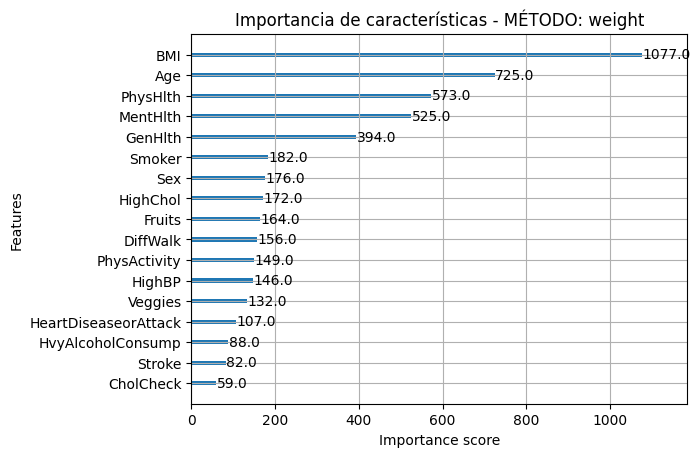

<Figure size 1000x600 with 0 Axes>

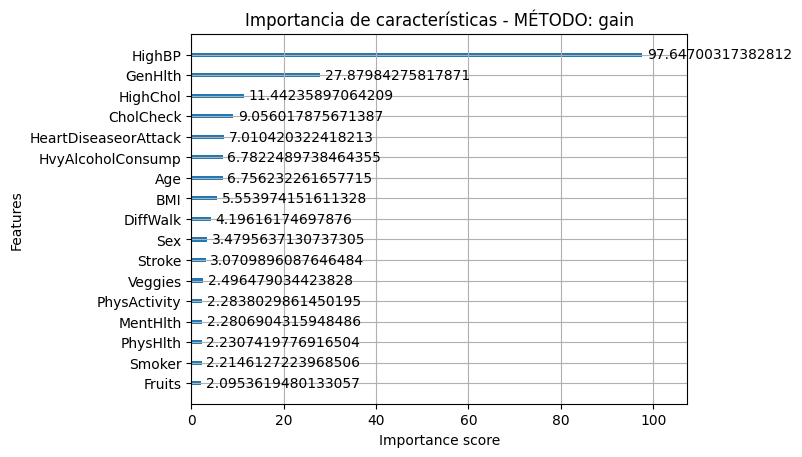

<Figure size 1000x600 with 0 Axes>

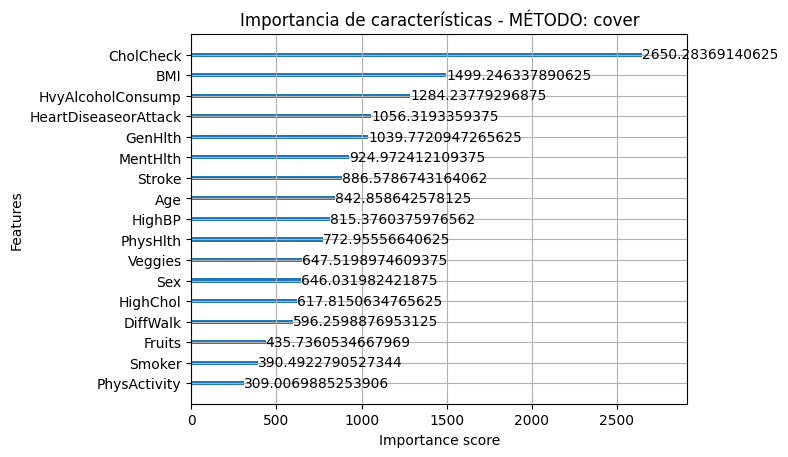

In [9]:
# Inserte su código aquí
import matplotlib.pyplot as plt
from xgboost import plot_importance

xgb_model = pipe.named_steps['model']

plt.figure(figsize=(10,6))
plot_importance(xgb_model, importance_type='weight')
plt.title("Importancia de características - MÉTODO: weight")
plt.show()

plt.figure(figsize=(10,6))
plot_importance(xgb_model, importance_type='gain')
plt.title("Importancia de características - MÉTODO: gain")
plt.show()

plt.figure(figsize=(10,6))
plot_importance(xgb_model, importance_type='cover')
plt.title("Importancia de características - MÉTODO: cover")
plt.show()

1. ¿Los resultados obtenidos con los diferentes métodos son compatibles?, comente sus resultados y a que se debe la igualdad o desigualdad que ve en los resultados. 
Los resultados obtenidos con los diferentes métodos no son compatibles entre sí. 
- weight: el número de veces que una característica es usada para dividir los datos en todos los árboles del modelo. 
- cover: la cobertura promedio en todas las divisones en las que se utiliza la característica. 
- gain: la ganancia promedio en todas las divisiones en las que se utiliza la característica.
Cada uno de estos métodos mide la importancia de las características desde una perspectiva diferente, lo que efectivamente llevó a resultados distintos en lo graficado.

Tenemos que en todos los métodos la carcaterística considerada más importante es distinta. En weight se tiene BMI, en gain High BP y en cover CholCheck.

3. Finalmente, ¿las importancias obtenidas son suficientes para obtener la interpretabilidad de un modelo que utiliza árboles? ¿Qué debilidad presenta este método? 
No, no son suficientes. Estas nos dan una idea general de qué características son relevantes, pero no se puede obtener una interpretación detallada de cómo cada una de estas afecta a las predicciones del modelo. La debilidad entonces recae en que no dan información de la magnitud y dirección de la influencia de cada característica en las diferentes predicciones y tampoco cómo interactúan entre sí. 

## 4. Métodos Agnósticos Globales (10 puntos)

<p align="center">
  <img src="https://media.tenor.com/JcRHtjVuXN8AAAAC/dr-simi-farmacias-similares.gif" width="400">
</p>

Tareas:
1. Para mitigar los problemas encontrados en la sección anterior, Dr. Simi le pide implementar un **método de permutación** que le permita observar la importancia de las features. `Nota:`Tenga cuidado con el orden de las columnas de este método. `Hint:` Puede obtener los features del clasificador con su respectivo orden mediante el método `.get_booster().feature_names` (2 puntos)
2. Para que su modelo sea consistente, repita el proceso **30 veces** y verifique la desviación estándar de sus resultados (¿Qué señala esta?). (2 puntos)
3. Visualice los resultados de este método en un gráfico. (2 puntos)
4. Además, responda las siguientes preguntas:
  - ¿Cómo mide la importancia de las features su propuesta? (1 punto)
  - ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)
  - ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)
  - Nombre y explique 3 ventajas y 3 desventajas del método implementado. (1 punto)

In [10]:
# Inserte su código aquí
from sklearn.inspection import permutation_importance
xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

# Preprocesamiento al conjunto de test (manteniendo el orden correcto)
X_test_transformed = preprocessor.transform(X_test)

# Que los nombres de columnas coincidan con el booster
feature_names = xgb_model.get_booster().feature_names

result = permutation_importance(
    xgb_model, X_test_transformed, y_test, n_repeats=30, random_state=6, n_jobs=-1
)

In [11]:
summary = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': result['importances_mean'],
    'std_importance': result['importances_std']
})
summary

,feature,mean_importance,std_importance
0,Age,0.026546,0.001551
1,BMI,0.032695,0.001586
2,GenHlth,0.057910,0.002337
3,MentHlth,0.000083,0.000646
4,PhysHlth,0.001743,0.001122
5,Sex,0.003029,0.000846
6,HighChol,0.012126,0.001226
7,CholCheck,0.002958,0.000572
8,Smoker,0.000895,0.000654
9,HeartDiseaseorAttack,0.003481,0.000633


Al analizar los valores de desviación estándar obtenidos por las 30 repeticiones, se observa que algunas características tienen una desviación estándar relativamente más alta. Esto indica que la importancia de estas varía más entre las diferentes ejecuciones de este método. Esto puede indicar que la importancia de aquellas es más sensible a la aleatoriedad de las permutaciones, lo que nos dice que no son robustas para el análsis.

/var/folders/dk/d3f73_m53n70_mwg1k58cxxm0000gn/T/ipykernel_62634/3649109230.py:2: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



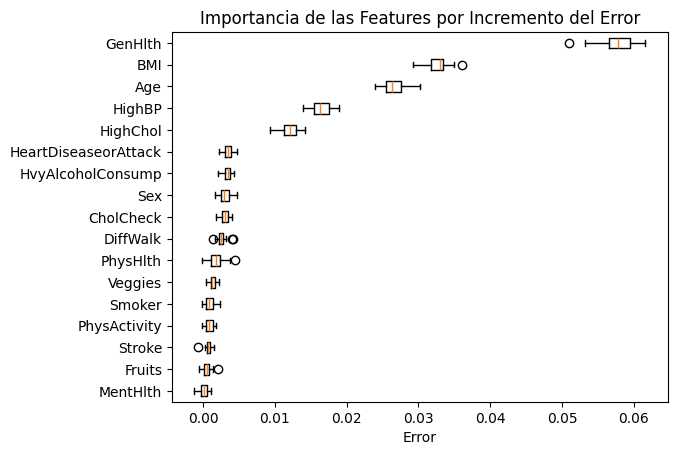

In [12]:
perm_sorted_idx = result.importances_mean.argsort()
plt.boxplot(
    result.importances[perm_sorted_idx].T,
    vert=False,
    labels=np.array(feature_names)[perm_sorted_idx],
)
plt.title("Importancia de las Features por Incremento del Error")
plt.xlabel('Error')
plt.show()

- ¿Cómo mide la importancia de las features su propuesta? (1 punto)

Lo que hace es medir el incremento del error (Feature Importance) en la predicción del modelo después de haber permutado valores en las features. Si al permutar una feature el error del modelo aumenta significativamente, entonces esa feature sería considerada importante para el modelo->su alteración afectó en el desempeño del modelo.

- ¿Qué features tienen un mayor impacto en la salida del modelo?. Comente las 5 primeras, ¿tienen sentido? (1 punto)

Las 5 features con mayor impacto en la salida del modelo son:
1. GenHlth
2. BMI
3. Age
4. HighBP
5. HighChol
Sí tienen sentido, todas están relacionadas con la salud y factores de riesgo para la diabetes. Los dos primeros indican cómo está la salud metabólica y el peso corporal -> si están mal se sabe que hay un mayor riesgo de diabetes. La edad también, ya que se suele manifestar en gente mayor. Finalmente, la hipertensión y el colesterol alto también son factores de riesgo conocidos para la diabetes.

- ¿Cómo cambian sus conclusiones con respecto a las features importances del punto anterior? (1 punto)

Con respecto al punto anterior, ahora podemos analizar de forma directa cómo cada feature afecta al desempeño del modelo. Antes no podíamos ver la influencia directa de cada una en las predicciones en sí. En cambio ahora podemos ver que features que no parecían tan importantes en los métodos anteriores (como Age y HighChol) tienen un impacto significativo en el desempeño. Esto nos da una visión más completa de la importancia de cada feature.

- Nombre y explique 3 ventajas y 3 desventajas del método implementado. 

Ventajas:
1. Fácil interpretación: intuitivo y fácil de entender
2. Alta compresión de interpretabilidad global: da una visión general de la importancia de las features en todo el modelo.
3. No necesita re-entrenar el modelo: solo requiere hacer predicciones con el modelo ya entrenado.

Desventajas:
1. Si las features están correlacionadas puede generar sesgos por entradas poco realistas: al permutar una feature, se pierde la relación con otras features correlacionadas, lo que puede llevar a interpretaciones erróneas.
2. Añadir una feature correlacionada puede decrecer la importancia de una feature asociada al separar la importancia en las dos features: al tener dos features que aportan información similar, la importancia se divide entre ellas, haciendo que cada una parezca menos importante de lo que realmente es la que ya estaba previamente.
3. Enlazado al error del modelo: si el modelo tiene un error alto, las importancias serían menos confiables.

## 5. Métodos Agnósticos Locales (20 puntos)

<p align="center">
  <img src="https://i.makeagif.com/media/10-24-2024/oMCrLI.gif" width="400">
</p>

### 5.1 Calculando Shap Values (4 puntos)

Tareas:
1. Alegre por saber cómo funciona el modelo de predicción a nivel general, Dr. Simi le pide ahora interpretar las predicciones de su modelo a nivel de paciente (es decir, desde un punto de vista **local**). Para esto, el ilustre farmacéutico le pide calcular los *shap values* de su modelo. (2 puntos)
2. ¿Qué representa cada número en su resultado? (1 punto)
3. ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

In [13]:
!pip install shap

In [14]:
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")

In [15]:
# Inserte código para calcular shapley values aquí
import shap

xgb_model = pipe.named_steps['model']
preprocessor = pipe.named_steps['preprocessor']

X_test_transformed = preprocessor.transform(X_test)
feature_names = xgb_model.get_booster().feature_names

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_df.head()

/Users/delaneytello/Desktop/Laboratorio_ciencia_datos/alibi-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



,Age,BMI,GenHlth,MentHlth,PhysHlth,Sex,HighChol,CholCheck,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Stroke,HighBP
0,-1.513311,-0.362227,-1.919941,0.066625,-0.130387,0.028823,-0.314679,0.030446,-0.008123,-0.077152,-0.058265,-0.032957,-0.015467,0.004426,-0.072989,-0.019769,-0.734552
1,0.252832,-0.089946,0.112321,0.012479,0.006049,-0.072533,0.258772,0.024470,0.027541,-0.034955,-0.023039,-0.030054,-0.027319,0.046729,0.114690,-0.008046,0.452289
2,0.711473,-0.233928,-0.537188,-0.001876,0.034436,0.121741,0.180570,0.019068,0.000653,-0.024016,-0.012967,-0.031461,-0.003156,0.021228,-0.055784,-0.011556,-0.585446
3,0.134519,-0.360024,0.533826,0.063611,0.010456,-0.049333,0.348676,0.033250,-0.001113,-0.071475,-0.000305,0.004186,-0.049378,0.034381,0.259791,-0.015804,-0.645156
4,-1.412740,-0.734273,-1.759928,0.081905,-0.052842,0.377331,-0.376095,0.030976,0.007837,-0.056190,-0.007468,-0.113071,-0.043568,0.002333,-0.071867,-0.009054,-0.932998


- ¿Qué representa cada número en su resultado? (1 punto) ¿Es posible atribuir un significado a la positividad/negatividad de cada valor? (1 punto)

Cada número en el resultado representa la contribución de una característica a la predicción. Si es positiva, entonces está aportando a que la predicción sea más alta (que sí tenga diabetes), y si es negativa, está aportando a que la predicción sea más baja (que no tenga diabetes). Luego, su magnitud nos dice que tan fuerte es esa contribución.


### 5.2 Aporte local (4 puntos)

1. Usando los *shap values* calculados, grafique el **aporte local** de las diferentes variables para las instancias **1**, **9** y **150** (1 punto).

2. Interprete sus resultados y responda:

  - ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

  - ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

  - ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)


 Paciente 1 — Real=1.0, Predicho=1


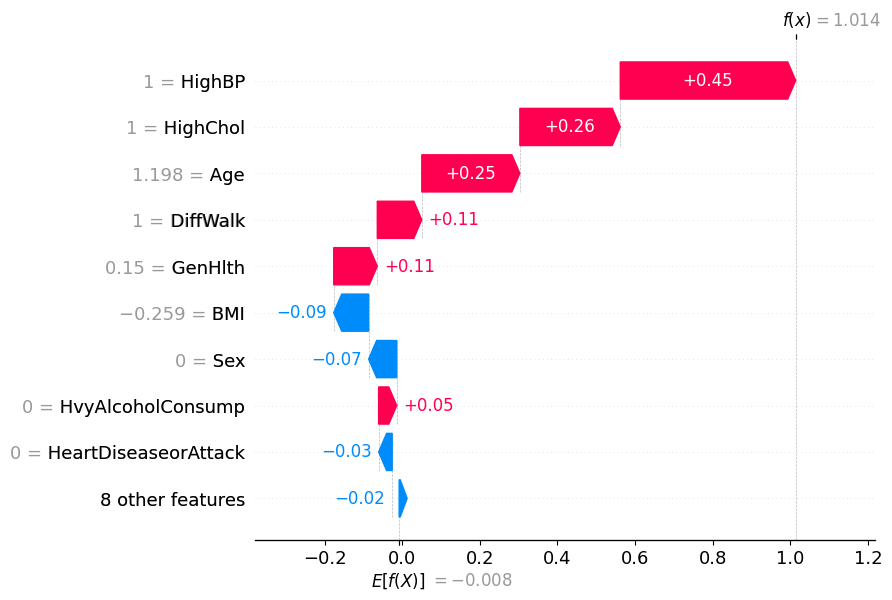


 Paciente 9 — Real=1.0, Predicho=1


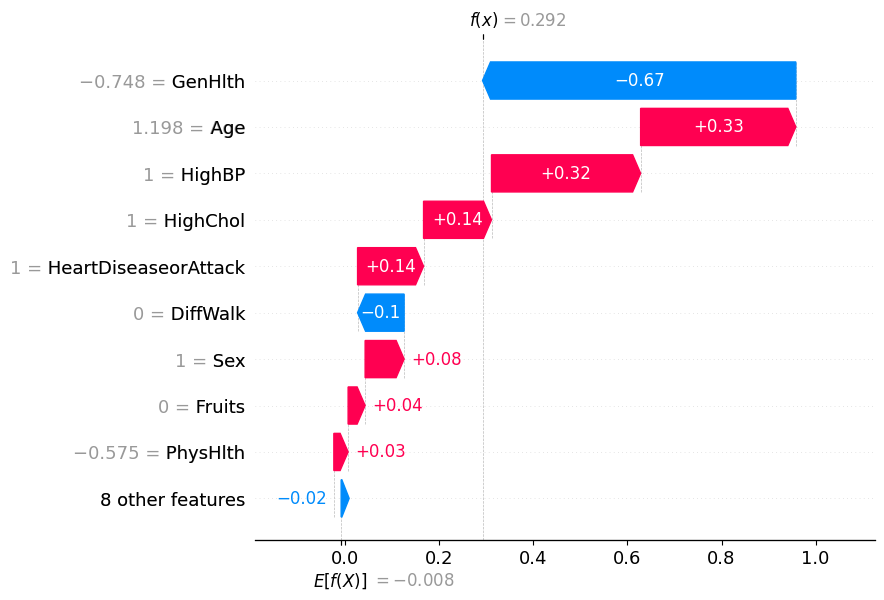


 Paciente 150 — Real=0.0, Predicho=0


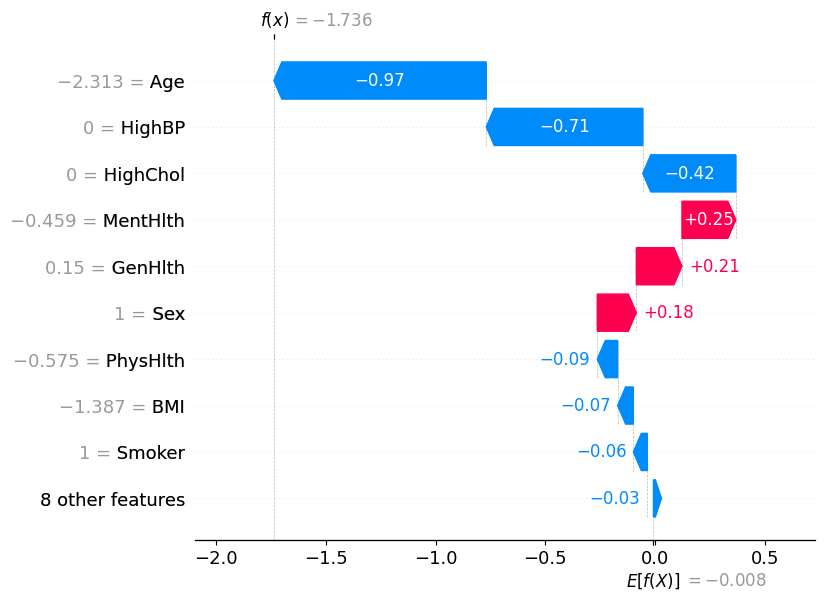

In [16]:
# Inserte código para generar gráficos de aporte local aquí

indices = [1, 9, 150]

for i in indices:
    print(f"\n Paciente {i} — Real={y_test.reset_index(drop=True).iloc[i]}, Predicho={pipe.predict(X_test.iloc[[i]])[0]}")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i],
            base_values=explainer.expected_value,
            data=X_test_transformed.iloc[i],
            feature_names=feature_names
        )
    )

- ¿Qué variables afectan de manera positiva/negativa a la probabilidad de poseer diabetes? (1 punto)

Las variables que afectan son: Age, HighBP, HighChol, BMI, MentHlth, GenHlth, PhysHlth, DiffWalk, Sex, HvyAlcoholConsump, HeartDiseaseorAttack, Fruits, Smoker.

- ¿Existe algún patrón común entre las instancias analizadas? (1 punto)

Sí, se puede observar que los valores que adquieren las variables afectan de forma consistente a la predicción. Por ejemplo, en las tres instancias, un valor alto de Age tiende a aumentar la probabilidad de diabetes, mientras que un sex=0 la disminuye. Además, la presencia de condiciones como HighBP y HighChol también aumenta la probabilidad en todas las instancias analizadas.

- ¿Es posible generalizar estas conclusiones a todo el dataset? (1 punto)

No del todo, ya que estas conslusiones son solo instanciales y estos comportamientos se manifiestan a partir de los valores específicos de las features y su combinación en cada instancia. Para poder generalizar, se necesitaría analizar un mayor número de ejemplos y observar si estos patrones se mantienen consistentemente en todo el dataset.

### 5.3 Aporte global (4 puntos)

Genere ahora una visualización donde se grafique el aporte de cada feature a nivel **global** e interprete sus resultados. ¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

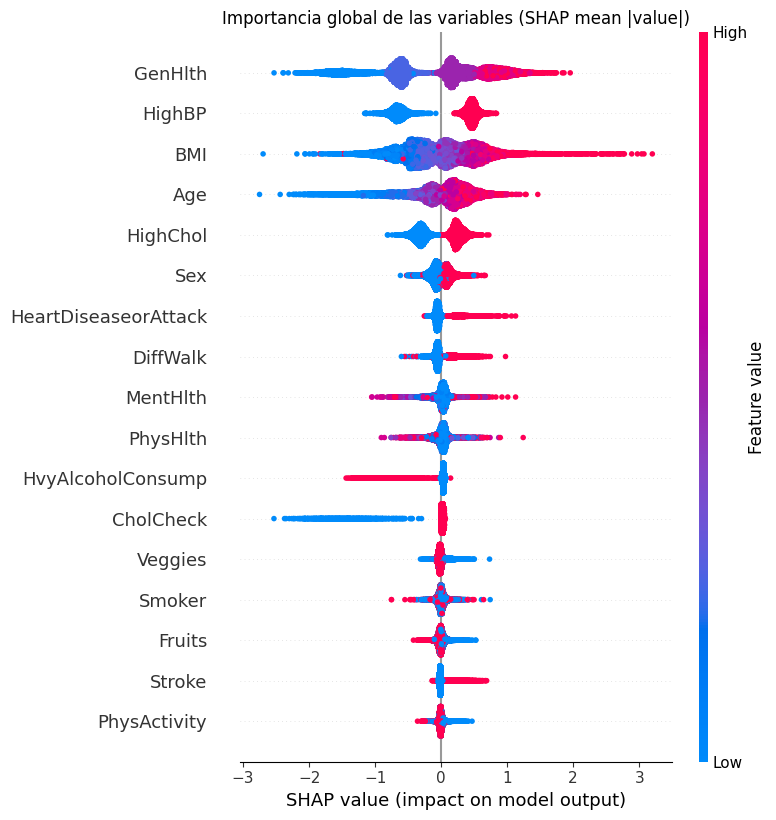

In [17]:
# Inserte código para generar gráficos de aporte global aquí
plt.title("Importancia global de las variables (SHAP mean |value|)")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

¿Qué diferencias existen con las conclusiones generadas a nivel de instancia?

Podemos ver que las más influyectes si fueron destacadas a nivel local, como Age, BMI, HighBP y GenHlth, pero en las anteriores el nivel de importancia de estas variaba según la instancia y se destacaban otras. Así, ahora tenemos una visión más clara de cuáles son las más relevantes en general.

### 5.4 Scatter plot (4 puntos)


Grafique ahora un *scatterplot* entre los *shap values* y las primeras 5 features con mayor impacto global (un gráfico por cada feature), coloreando cada punto por la probabilidad de tener diabetes. ¿Qué puede concluir de sus resultados?

Top 5 features más influyentes: ['GenHlth' 'HighBP' 'BMI' 'Age' 'HighChol']


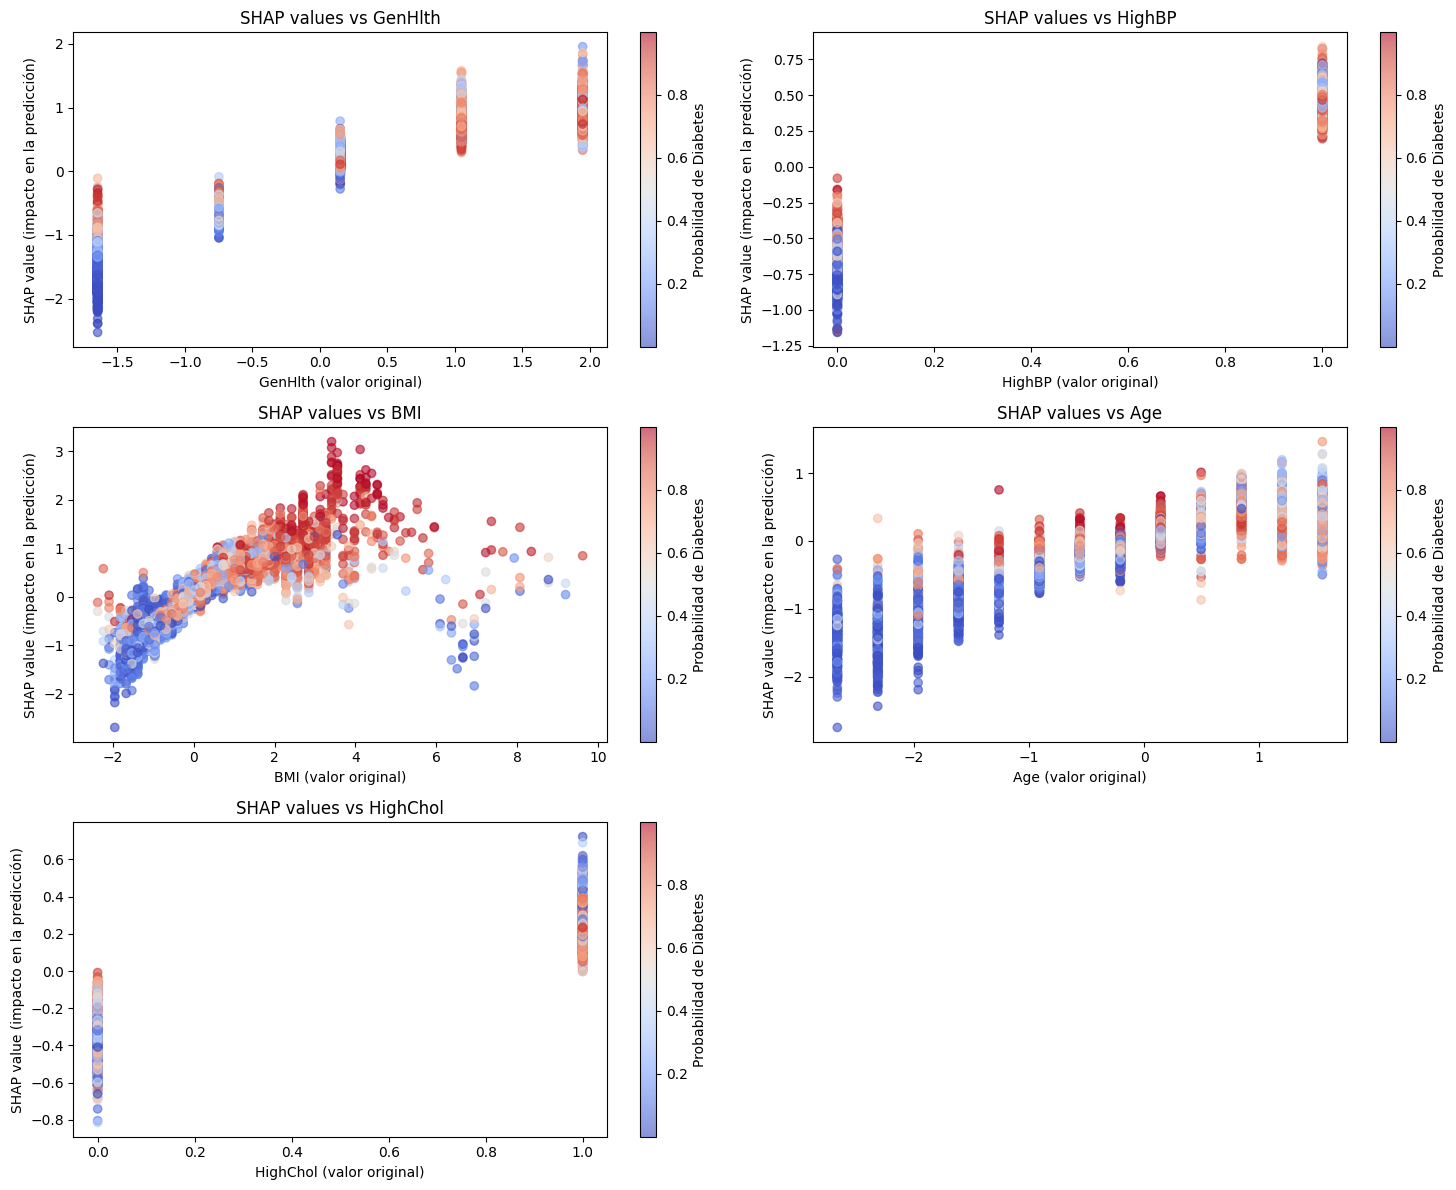

In [18]:
# Probabilidades predichas
y_proba = pipe.predict_proba(X_test)[:, 1]

#Identificar las 5 variables más influyentes globalmente
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top5_idx = np.argsort(mean_abs_shap)[::-1][:5]
top5_features = np.array(feature_names)[top5_idx]

print("Top 5 features más influyentes:", top5_features)

plt.figure(figsize=(15, 12))
for i, feat in enumerate(top5_features, 1):
    plt.subplot(3, 2, i)
    plt.scatter(
        X_test_transformed[feat],
        shap_values[:, top5_idx[i-1]],
        c=y_proba,
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Probabilidad de Diabetes')
    plt.title(f"SHAP values vs {feat}")
    plt.xlabel(f"{feat} (valor original)")
    plt.ylabel("SHAP value (impacto en la predicción)")
plt.tight_layout()
plt.show()

- GenHlth: a medida que el valor de esta aumenta, el SHAP value también tiende a aumentar. Aquello indica que un peor estado de salud general implica una mayor probabilidad de tener diabetes. Además, los puntos con valores altos de GenHlth tienden a tener colores más cálidos (probabilidades más altas de diabetes).
- HighBP: Claramente se observa que con valor 1 los SHAP values son mayores y positivos, lo que implica que tener hipertensión aumentaría la probabilidad de tener diabetes. Aquello se ve reflejado en las tonalidades más cálidas en la región de HighBP=1.
- BMI: Vemos que con valores bajos, los valores SHAP son negativos y las predicciones tienden a ser bajas (colores azules). Luego, el comportamiento no es muy lineal, ya que al principio se ve que al aumentar el BMI, los SHAP values también, pero luego se estabilizan y hasta disminuyen un poco. Sin embargo, en general, un BMI más alto tiende a asociarse con una mayor probabilidad de diabetes.
- Age: En general si age aumenta, los SHAP values también, pero vemos que para edades muy altas o muy bajas, los valores SHAP tienden a ser más dispersos. Igualmente se observa que para edades más altas predominan los colores cálidos, indicando una mayor probabilidad de diabetes.
- HighChol: Similar a HighBP, se observa que con valor 1 los SHAP values son mayores y positivos, lo que implica que tener colesterol alto aumentaría la probabilidad de tener diabetes. Aquello se ve reflejado en las tonalidades más cálidas en la región de HighChol=1 (aunque no está tan marcada esta diferencia, hay varios puntos azules también).

### 5.5 Partial Dependence Plot (4 puntos)

Finalmente, se le pide generar un gráfico del tipo Partial Dependence Plot para las mismas 5 variables con mayor impacto global usando una submuestra de 1000 observaciones. ¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

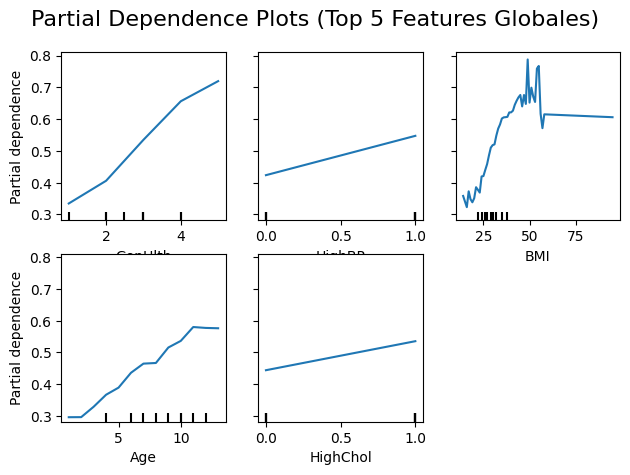

In [19]:
from sklearn.inspection import PartialDependenceDisplay

# Submuestra de 1000 observaciones
subsample_idx = np.random.choice(X_test.index, size=1000, replace=False)
X_sub = X_test.loc[subsample_idx]

# Graficar PDP para las 5 features principales
PartialDependenceDisplay.from_estimator(
    pipe,
    X_sub,
    features=top5_features,
    kind='average',
    n_jobs=-1
)
plt.suptitle("Partial Dependence Plots (Top 5 Features Globales)", fontsize=16)
plt.tight_layout()
plt.show()

¿Qué relación existe entre la salida promedio del modelo y cada feature analizada? ¿Son estas conclusiones generalizables para todo el conjunto de datos?

En casi todas las variables se observa una relación positiva con la salida promedio del modelo, a medida que el valor de la feature aumenta, la salida también tiende a aumentar. Sin embargo, esto no se da en todas, ya que BMI tiene un comportamiento complejo, similar a lo visto previamente en el scatter plot, en donde al inicio se ve un aumento pero luego se mantiene entre cierto rango para luego empezar a disminuir, teniendo al final un peak.

Con respecto a si son generalizables, se posdría decir que sí porque se usa el promedio de las predicciones del modelo en cierta submuestra, lo que da una idea de la tendencia general. Sin embargo, una submuestra puede no capturar todas las variaciones en el conjunto completo de datos, por lo que sería bueno usar más subconjuntos u otros métodos para complementar y confirmar las conclusiones.

## 6. Sistema de Reglas! (10 punto)

<p align="center">
  <img src="https://media.baamboozle.com/uploads/images/125978/1638281150_1380186_gif-url.gif" width="400">
</p>

Después de todo el trabajo hecho, Dr. Simi le pide simplificar el funcionamiento de su modelo en un sistema de reglas que le permita explicar a sus clientes las predicciones que genera su modelo.
En particular, Dr. Simi le pide explicar la decisión tomada para las observaciones **1000**, **3001** y **5751**. Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

`Hint:` Como debe entregar las columnas que entran al clasificador entrenado de su pipeline, le será útil extraer el paso de preprocesamiento y generar dataframes preprocesados para el conjunto `train` y `test`.

In [20]:
preprocessor = pipe.named_steps['preprocessor']
xgb_model = pipe.named_steps['model']

X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names)
X_test_prep = pd.DataFrame(X_test_prep, columns=feature_names)


print(X_train_prep.shape, X_test_prep.shape)

(47128, 17) (23564, 17)


In [25]:
import pandas as pd
from alibi.explainers import AnchorTabular

# creamos función de predicción
predict_fn = lambda x: pipe.predict(pd.DataFrame(x, columns=feature_names))

explainer = AnchorTabular(predict_fn, feature_names=feature_names, seed=6)

# Ajustamos el explicador con los datos preprocesados
explainer.fit(X_train_prep.values)


idx = 1000
instance = X_test_prep.iloc[idx].values.reshape(1, -1)
explanation = explainer.explain(instance)
print('#'*10,str(idx),'#'*10)
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print(f"Precisión: {explanation.precision:.2f}")
print(f"Cobertura: {explanation.coverage:.2f}")
print(f"Predicción del modelo: {pipe.predict(X_test.iloc[[idx]])[0]}")

idx = 3001
instance = X_test_prep.iloc[idx].values.reshape(1, -1)
explanation = explainer.explain(instance)
print('#'*10,str(idx),'#'*10)
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print(f"Precisión: {explanation.precision:.2f}")
print(f"Cobertura: {explanation.coverage:.2f}")
print(f"Predicción del modelo: {pipe.predict(X_test.iloc[[idx]])[0]}")

idx = 5751
instance = X_test_prep.iloc[idx].values.reshape(1, -1)
explanation = explainer.explain(instance)
print('#'*10,str(idx),'#'*10)
print('Anchor: %s' % (' AND '.join(explanation.anchor)))
print(f"Precisión: {explanation.precision:.2f}")
print(f"Cobertura: {explanation.coverage:.2f}")
print(f"Predicción del modelo: {pipe.predict(X_test.iloc[[idx]])[0]}")




########## 1000 ##########
Anchor: DiffWalk <= 0.00
Precisión: 0.98
Cobertura: 0.75
Predicción del modelo: 1
########## 3001 ##########
Anchor: DiffWalk <= 0.00
Precisión: 0.96
Cobertura: 0.74
Predicción del modelo: 1
########## 5751 ##########
Anchor: HighBP <= 0.00
Precisión: 1.00
Cobertura: 0.43
Predicción del modelo: 0


Con las reglas propuestas señale a **cuánta población** es posible explicar con estas reglas e indique la **precisión** que poseen las reglas en la totalidad de los datos. ¿Tienen sentido sus reglas propuestas para las observaciones?. Fundamente sus respuesta señalando el impacto que tienen sus reglas sobre todo el conjunto de datos.

Considerando que:

- precision: indica cuán fiable es la regla. Es la proporción de veces que, si se cumple la condición, el modelo efectivamente predice ese valor.
- coverage: indica qué porcentaje del conjunto de datos cumple esa regla. Representa la fracción de la población a la que aplica esa explicación.

Entonces podemos concluir que las reglas generadas explican el 75%, 74% y 43% de la población respectivamente. Por lo tanto, permiten explicar gran parte de la población. 

Por otro lado, las precisiones son muy altas (0.98, 0.96 y 1 respectivamente) lo cual nos indica que cuando la condición del anchor se cumple, el modelo casi siempre predice el mismo resultado, es decir, es confiable.

Con respecto a si tienen sentidos, podemos ver que son consistentes (las dos primeras inducen predicciones de diabetes y la última no). Además, HighBP indica hipertensión, no tener hipertensión podría estar asociado a no riesgo, lo cual concuerda con una predicción “0”. En cambio, tener DiffWalk <=0(no tener dificultad para caminar) indica diabetes según la regla, lo cual no es muy intuitivo pero que al parecer por las métricas obtenidas, es así.

Con respecto al impacto en el conjunto de datos, como ya se mencionó, las reglas cubren gran parte de la población y tienen una gran precisión, lo que indica que son potencialmente representativas y confiables para explicar las predicciones del modelo.

# Retrospectiva... (10 puntos)

En base a los diferentes métodos que implementa y ha comentado en este laboratorio, comente qué métodos le permiten entregar mejores conclusiones para la tarea de clasificación de diabetes. Por otro lado, ¿qué métodos son más útiles para el problema del doctor Simi, métodos agnosticos locales o globales?

> Fundamente su Respuesta aquí

A nivel global, los métodos Permutation Feature Importance y Partial Dependence Plots (PDP) entregan una visión general del modelo, permitiendo identificar qué variables tienen mayor impacto promedio sobre la probabilidad de diabetes. Estos métodos resultan muy útiles para analizar patrones globales y validar que el modelo haya aprendido relaciones coherentes con la evidencia médica, como la influencia del índice de masa corporal (BMI), la edad o la presión arterial alta (HighBP). Sin embargo, no permiten entender decisiones específicas sobre pacientes individuales.

Por otro lado, los métodos locales como SHAP Values y AnchorTabular entregan explicaciones caso a caso. Los SHAP permiten cuantificar cuánto aporta cada variable a la predicción de un paciente en particular (tanto positiva como negativamente), mientras que las reglas tipo Anchor generan condiciones simples y comprensibles (“if–then”) que explican por qué el modelo clasificó a una persona como diabética o no.

Para la tarea general de clasificación de diabetes, los métodos globales son los que permiten obtener las mejores conclusiones: ayudan a comprender el funcionamiento general del modelo, validar su coherencia con la medicina y detectar posibles sesgos. Sin embargo, para el problema del Dr. Simi, cuyo objetivo es explicar a los pacientes sus diagnósticos de manera comprensible, los métodos agnósticos locales son los más útiles, ya que permiten justificar decisiones individuales con ejemplos claros y personalizados. 

En resumen, los métodos globales ayudan a confiar en el modelo, mientras que los locales permiten explicarlo a las personas, siendo ambos complementarios pero con distintos propósitos dentro del análisis clínico.